# Глава 2. Архитектура и компоненты

## 2.1. Основные компоненты RAG‑систем

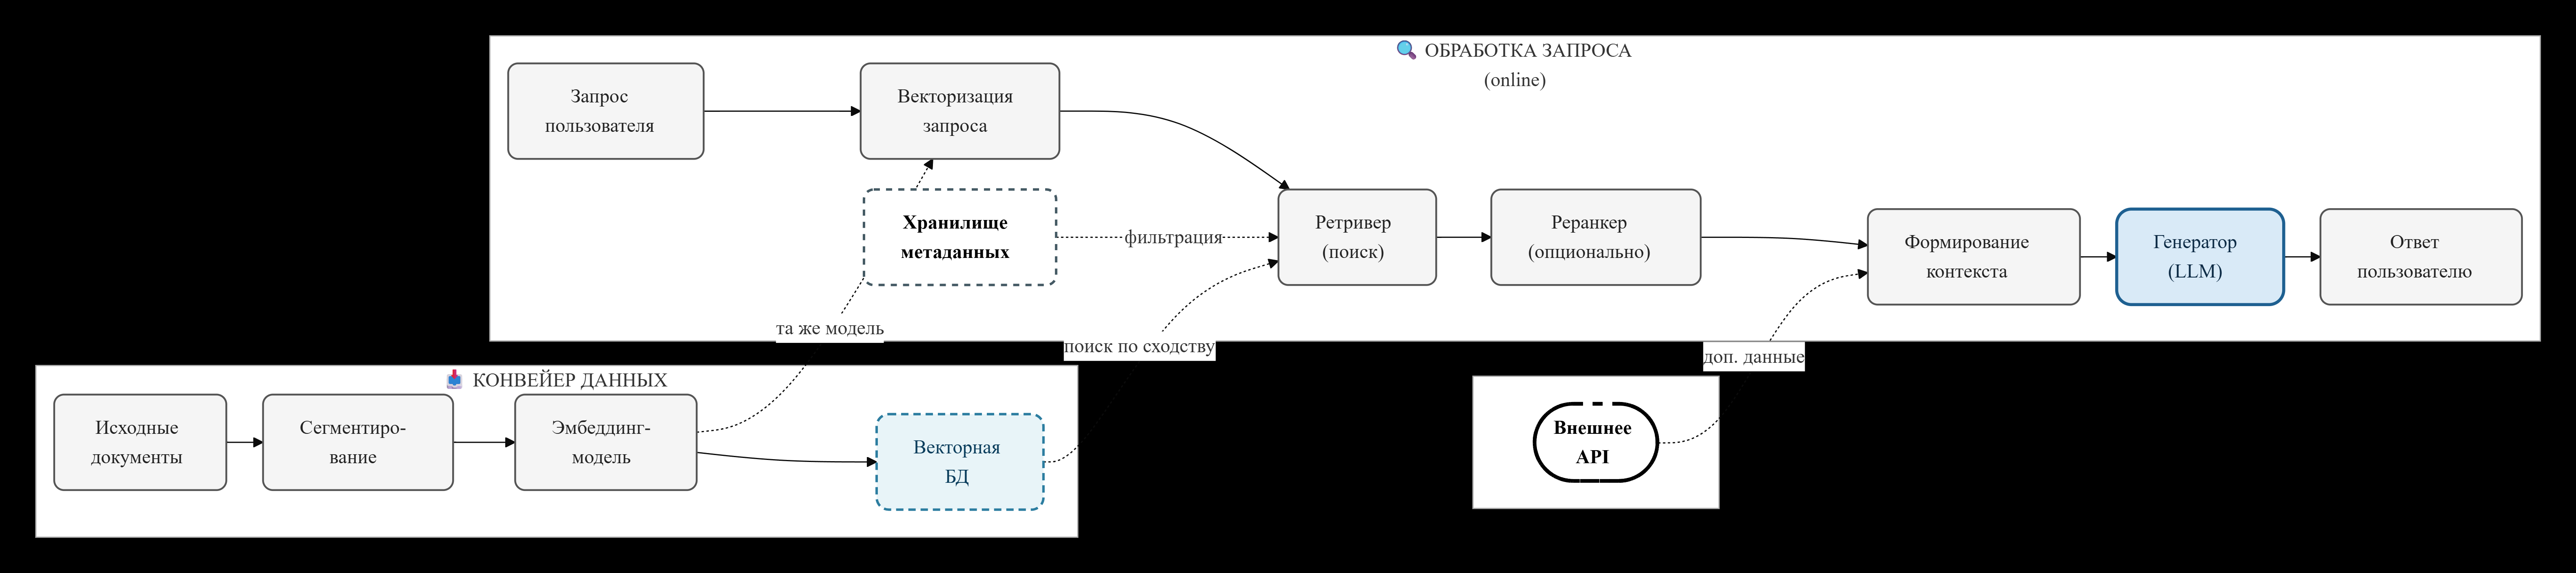

### Общая логика архитектуры

Схема отражает два основных потока:  
* **офлайн‑подготовку данных** — формирует основу знаний системы; качество этого этапа задаёт верхний предел эффективности RAG;  
* **онлайн‑обработку запросов** — отвечает за скорость ответа и пользовательский опыт.

### Конвейер данных: офлайн‑подготовка

Этот этап создаёт базу знаний для RAG‑системы и включает последовательные шаги:

1. **Загрузка и нормализация исходных документов** из разнородных источников: текстовых файлов, PDF, веб‑страниц, записей из баз данных. Для работы с разными форматами требуются универсальные загрузчики, способные извлекать чистый текст.  
2. **Сегментирование (чанкирование)** — разбиение документов на логически связанные фрагменты оптимального размера (обычно 100–1000 токенов). Критически важно соблюсти баланс: слишком маленькие чанки теряют контекст, слишком большие могут содержать разнородную информацию, снижающую точность поиска.  
3. **Преобразование в эмбеддинги** с помощью эмбеддинг‑модели: текстовые фрагменты кодируются в числовые векторы, отражающие их семантическое содержание. Выбор модели критичен — она должна эффективно работать с предметной областью и языком документов.  
4. **Хранение в векторной базе данных**, оптимизированной для быстрого поиска высокомерных векторов. Среди современных решений упоминаются Pinecone, Weaviate, Qdrant, Chroma — они предлагают разные компромиссы между скоростью, точностью и функциональностью.

### Обработка запросов: онлайн‑поток

При поступлении пользовательского запроса система выполняет следующие действия:

* **Векторизация запроса** с использованием той же эмбеддинг‑модели, что применялась при индексации документов. Это обеспечивает совместимость векторных представлений и корректность поиска по сходству.  
* **Работа ретривера (retriever)** — семантический поиск в векторном пространстве для нахождения K наиболее похожих фрагментов. Современные ретриверы поддерживают гибридный поиск, комбинируя векторное сходство с лексическими методами (например, BM25) для повышения точности.  
* **Опциональная работа реранкера (reranker)** — специализированные модели анализируют найденные фрагменты в контексте конкретного запроса и переранжируют их, более точно оценивая релевантность. Это особенно эффективно при работе со сложными или многоаспектными запросами.

### Дополнительные компоненты

В архитектуре также задействованы:  
* хранилище метаданных (с функцией фильтрации);  
* внешние API (для получения дополнительных данных);  
* генератор на базе LLM — формирует итоговый ответ пользователю на основе собранного контекста.

### Формирование контекста и генерация

На этом этапе система превращает найденные фрагменты в осмысленный ответ:

* **Модуль аугментации (augmentation)** объединяет релевантные фрагменты с исходным запросом пользователя, формируя расширенный промпт для языковой модели. В рамках аугментации часто выполняют дополнительную обработку: сжатие контекста (чтобы уложиться в лимиты токенов), удаление дубликатов и структурирование информации (например, в виде списка или JSON).  
* **Генератор (LLM)** получает обогащённый контекст и формирует финальный ответ. Ключевое преимущество такого подхода — модель опирается не только на свои параметрические знания (заложенные при обучении), но и на предоставленную актуальную информацию. Это существенно снижает количество галлюцинаций и повышает достоверность ответа.

### Дополнительные компоненты

Эти модули расширяют функциональность и встраивают RAG в корпоративную среду:

* **Хранилище метаданных** дополняет поиск атрибутами документов: дата создания, автор, категория, права доступа. Это позволяет фильтровать результаты и обеспечивать релевантность на уровне бизнес‑логики (например, показывать только документы с уровнем допуска «для сотрудников отдела»).  
* **Внешние API** интегрируют RAG с корпоративными системами (CRM, ERP) и внешними сервисами, превращая его в универсальный интерфейс к экосистеме данных.  
* **Подсистема мониторинга и журналирования** отслеживает качество работы каждого компонента. В неё входят метрики производительности, анализ пользовательской активности и A/B‑тестирование разных конфигураций. Хотя эта подсистема не показана на архитектурных диаграммах (она как бы охватывает все компоненты), она критически важна для непрерывного улучшения системы.

### Модульность и масштабируемость

Это ключевое преимущество RAG‑архитектуры:

* **Независимое масштабирование.** Каждый компонент можно оптимизировать отдельно: эмбеддинг‑модель — заменить на более эффективную, векторную БД — масштабировать горизонтально, ретривер — настроить под специфику предметной области.  
* **Итеративное развитие.** Архитектура позволяет начать с простой реализации и постепенно наращивать сложность: добавлять реранкинг, гибридный поиск, поддержку мультимодальных данных или агентские возможности. Такой подход делает RAG идеальной технологией для развивающихся продуктов.  

Понимание роли каждого компонента и принципов их взаимодействия — основа для проектирования эффективных RAG‑систем. В следующих разделах книги рассматриваются архитектурные паттерны и методы интеграции этих компонентов в единую высокопроизводительную систему.